# AI Content Optimization Tool

## Import Libraries

In [1]:
import re
import nltk
import textstat
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud

## Load Input Text

In [2]:
try:
    with open("sample_text.txt", "r", encoding="utf-8") as file:
        text = file.read()
    print("Text loaded successfully.\n")
    print(text[:300])   # preview first 300 characters
except FileNotFoundError:
    print("sample_text.txt not found. Please keep it in the same folder as the notebook.")

Text loaded successfully.

GENERATIVE ENGINE OPTIMIZATION

Generative Engine Optimization is the process of optimizing content
so that it performs well in AI-driven search engines such as ChatGPT,
Perplexity, and other generative search systems.

WHY CONTENT STRUCTURE MATTERS

Well-structured content helps users and AI system


## Text Preprocessing

In [3]:


sentences = sent_tokenize(text)
words = word_tokenize(text.lower())

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

print("Total sentences:", len(sentences))
print("Total filtered words:", len(filtered_words))
print("Sample filtered words:", filtered_words[:15])

Total sentences: 5
Total filtered words: 65
Sample filtered words: ['generative', 'engine', 'optimization', 'generative', 'engine', 'optimization', 'process', 'optimizing', 'content', 'performs', 'well', 'search', 'engines', 'chatgpt', 'perplexity']


## Readability Analysis

In [4]:

readability_score = textstat.flesch_reading_ease(text)
grade_level = textstat.flesch_kincaid_grade(text)

print("Readability Score:", round(readability_score, 2))
print("Grade Level:", round(grade_level, 2))

Readability Score: -1.27
Grade Level: 18.01


## Keyword Analysis

In [5]:
target_keyword = "optimization"
keyword_count = sum(1 for word in words if word == target_keyword.lower())

print(f"Keyword '{target_keyword}' appears {keyword_count} times.")

Keyword 'optimization' appears 2 times.


## Top Repeated Words

In [6]:


word_freq = Counter(filtered_words)
top_words = word_freq.most_common(10)

print("Top 10 Words:")
for word, count in top_words:
    print(word, ":", count)

Top 10 Words:
content : 5
generative : 3
geo : 3
engine : 2
optimization : 2
search : 2
systems : 2
information : 2
headings : 2
readability : 2


## Content Metrics

In [7]:
num_sentences = len(sentences)
num_words = len(filtered_words)
avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0

print("Number of Sentences:", num_sentences)
print("Number of Words:", num_words)
print("Average Sentence Length:", round(avg_sentence_length, 2))

Number of Sentences: 5
Number of Words: 65
Average Sentence Length: 13.0


## Heading Detection

In [8]:
lines = text.split('\n')
possible_headings = [line.strip() for line in lines if len(line.split()) < 8 and line.strip().isupper()]

print("Possible Headings:")
for h in possible_headings:
    print("-", h)

heading_count = len(possible_headings)
print("Total Headings Detected:", heading_count)

Possible Headings:
- GENERATIVE ENGINE OPTIMIZATION
- WHY CONTENT STRUCTURE MATTERS
- KEY FACTORS IN GEO
- BENEFITS OF GEO
Total Headings Detected: 4


## Lexical Diversity

In [9]:
unique_words = len(set(filtered_words))
lexical_diversity = unique_words / num_words if num_words > 0 else 0

print("Unique Words:", unique_words)
print("Lexical Diversity:", round(lexical_diversity, 2))

Unique Words: 50
Lexical Diversity: 0.77


## Suggestion Engine

In [10]:
suggestions = []

if readability_score < 60:
    suggestions.append("Improve readability by using shorter and simpler sentences.")

if grade_level > 10:
    suggestions.append("Simplify vocabulary and sentence structure to reduce reading difficulty.")

if keyword_count < 2:
    suggestions.append(f"Increase the usage of the keyword '{target_keyword}' naturally in the content.")

if keyword_count > 8:
    suggestions.append("Keyword appears too frequently. Reduce repetition to avoid keyword stuffing.")

if avg_sentence_length > 20:
    suggestions.append("Reduce average sentence length for better clarity.")

if num_words < 150:
    suggestions.append("Content is short. Add more useful information to improve discoverability.")

if heading_count == 0:
    suggestions.append("No headings detected. Add headings for better structure and readability.")

if heading_count < 2:
    suggestions.append("Add more headings or subheadings to improve content organization.")

if lexical_diversity < 0.5:
    suggestions.append("Vocabulary variety is low. Use more diverse wording to improve engagement.")

In [11]:
print("Suggestions:")
for i, suggestion in enumerate(suggestions, 1):
    print(f"{i}. {suggestion}")

Suggestions:
1. Improve readability by using shorter and simpler sentences.
2. Simplify vocabulary and sentence structure to reduce reading difficulty.
3. Content is short. Add more useful information to improve discoverability.


## Results Table

In [12]:


results = {
    "Metric": [
        "Readability Score",
        "Grade Level",
        "Keyword Count",
        "Total Sentences",
        "Total Words",
        "Average Sentence Length",
        "Total Headings",
        "Lexical Diversity"
    ],
    "Value": [
        round(readability_score, 2),
        round(grade_level, 2),
        keyword_count,
        num_sentences,
        num_words,
        round(avg_sentence_length, 2),
        heading_count,
        round(lexical_diversity, 2)
    ]
}

df = pd.DataFrame(results)
df

,Metric,Value
0,Readability Score,-1.27
1,Grade Level,18.01
2,Keyword Count,2.00
3,Total Sentences,5.00
4,Total Words,65.00
5,Average Sentence Length,13.00
6,Total Headings,4.00
7,Lexical Diversity,0.77


## Visualization

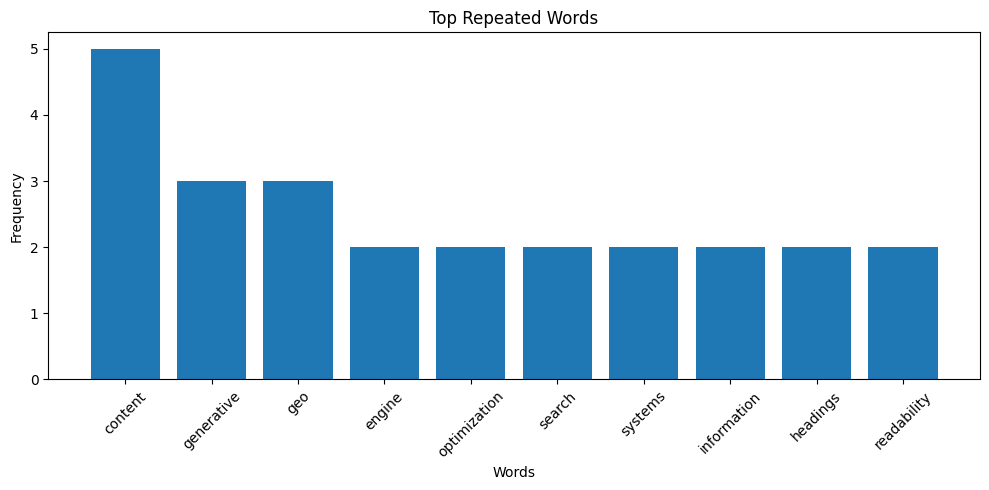

In [13]:
top_df = pd.DataFrame(top_words, columns=["Word", "Count"])

plt.figure(figsize=(10, 5))
plt.bar(top_df["Word"], top_df["Count"])
plt.title("Top Repeated Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

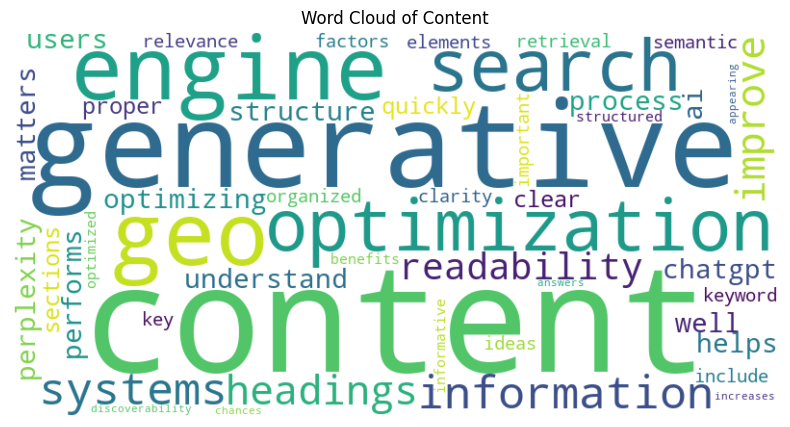

In [14]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Content")
plt.show()

## Final Function

In [15]:
def analyze_content(text, target_keyword):
    sentences = sent_tokenize(text)
    words = word_tokenize(text.lower())

    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

    readability_score = textstat.flesch_reading_ease(text)
    grade_level = textstat.flesch_kincaid_grade(text)

    keyword_count = sum(1 for word in words if word == target_keyword.lower())

    num_sentences = len(sentences)
    num_words = len(filtered_words)
    avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0

    lines = text.split('\n')
    possible_headings = [line.strip() for line in lines if len(line.split()) < 8 and line.strip().isupper()]
    heading_count = len(possible_headings)

    unique_words = len(set(filtered_words))
    lexical_diversity = unique_words / num_words if num_words > 0 else 0

    word_freq = Counter(filtered_words)
    top_words = word_freq.most_common(10)

    suggestions = []

    if readability_score < 60:
        suggestions.append("Improve readability by using shorter and simpler sentences.")
    if grade_level > 10:
        suggestions.append("Simplify vocabulary and sentence structure to reduce reading difficulty.")
    if keyword_count < 2:
        suggestions.append(f"Increase the usage of the keyword '{target_keyword}' naturally in the content.")
    if keyword_count > 8:
        suggestions.append("Keyword appears too frequently. Reduce repetition to avoid keyword stuffing.")
    if avg_sentence_length > 20:
        suggestions.append("Reduce average sentence length for better clarity.")
    if num_words < 150:
        suggestions.append("Content is short. Add more useful information to improve discoverability.")
    if heading_count == 0:
        suggestions.append("No headings detected. Add headings for better structure and readability.")
    if heading_count < 2:
        suggestions.append("Add more headings or subheadings to improve content organization.")
    if lexical_diversity < 0.5:
        suggestions.append("Vocabulary variety is low. Use more diverse wording to improve engagement.")

    return {
        "readability_score": round(readability_score, 2),
        "grade_level": round(grade_level, 2),
        "keyword_count": keyword_count,
        "num_sentences": num_sentences,
        "num_words": num_words,
        "avg_sentence_length": round(avg_sentence_length, 2),
        "heading_count": heading_count,
        "lexical_diversity": round(lexical_diversity, 2),
        "top_words": top_words,
        "suggestions": suggestions
    }

## Final Output

In [16]:
result = analyze_content(text, "optimization")
result

{'readability_score': -1.27,
 'grade_level': 18.01,
 'keyword_count': 2,
 'num_sentences': 5,
 'num_words': 65,
 'avg_sentence_length': 13.0,
 'heading_count': 4,
 'lexical_diversity': 0.77,
 'top_words': [('content', 5),
  ('generative', 3),
  ('geo', 3),
  ('engine', 2),
  ('optimization', 2),
  ('search', 2),
  ('systems', 2),
  ('information', 2),
  ('headings', 2),
  ('readability', 2)],
 'suggestions': ['Improve readability by using shorter and simpler sentences.',
  'Simplify vocabulary and sentence structure to reduce reading difficulty.',
  'Content is short. Add more useful information to improve discoverability.']}


This notebook analyzes content using NLP techniques and provides readability, keyword, structure, and vocabulary-based suggestions for improving content quality in GEO-related use cases.